# 01 Simple Perceptron

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement a single-layer perceptron
- Train on linearly separable data and interpret weights

## 🔗 Where this fits

**Builds on:** Unit 3, lesson 04 "Gradient Descent and Loss Functions" — the perceptron trains by the same recipe: define a loss, then nudge the weights downhill.

**Used later in:** Course 08 (AIAT 122) — Unit 1, where the single neuron becomes a deep network.

---


## 🎯 A machine with motors instead of weights

The perceptron you are about to code was, in 1958, a room. Frank Rosenblatt built
the **Mark I Perceptron** at the Cornell Aeronautical Laboratory with funding from
the US Office of Naval Research: a 20×20 grid of photocells looking at a card, and
weights stored as the settings of motor-driven potentiometers — physical dials
that the learning rule turned. Training was literally mechanical.

In July 1958 the New York Times, reporting the Navy's demonstration, told readers
this was "the embryo of an electronic computer that [the Navy] expects will be
able to walk, talk, see, write, reproduce itself and be conscious of its
existence". Eleven years later Minsky and Papert's *Perceptrons* (1969) proved
that a single layer of these units could not compute XOR, and funding for the
whole line of research collapsed for roughly fifteen years.

Both halves of that story are in the code below. **The learning rule genuinely
works** — you will watch it converge on the AND gate in four epochs, with no
calculus and no library. **And its hypothesis space is exactly one straight
line**, which is why the same rule cannot touch XOR (Unit 3, notebook 02).

### What goes wrong without the perceptron rule

Every trainable model in this diploma runs the same three-step loop: predict,
measure the error, adjust the parameters in the direction that reduces it. The
perceptron is that loop with everything else stripped away — no gradients, no
optimizer object, no framework. If you can read the eight lines that update `w`
and `b` below, you can read what Keras is doing in Unit 4 and what a transformer
is doing in Course 08. Skip it and every later `model.fit()` stays magic.


# 01 Simple Perceptron

## 📚 Learning Objectives

This notebook demonstrates key concepts through hands-on examples.

By completing this notebook, you will:
- Understand the core concepts
- See practical implementations
- Be ready for exercises

## 🔗 Prerequisites

- ✅ Python 3.8+ installed
- ✅ Required libraries (see `requirements.txt`)
- ✅ Basic Python knowledge

---

## Code Example

Run the code below to see the demonstration:

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

Example 1: Simple Perceptron

Example: AND Gate Classification

Training Data:
Input | Output
------|-------
[0 0]  |   0
[0 1]  |   0
[1 0]  |   0
[1 1]  |   1

Training Perceptron...
  Converged at epoch 4

Training complete!
Final weights: [0.2 0.1]
Final bias: -0.20000000000000004

Testing Perceptron

Predictions:
Input | Expected | Predicted | Correct
------|----------|-----------|--------
[0 0]  |    0     |     0     |   ✓
[0 1]  |    0     |     0     |   ✓
[1 0]  |    0     |     0     |   ✓
[1 1]  |    1     |     1     |   ✓

Accuracy: 100.0%


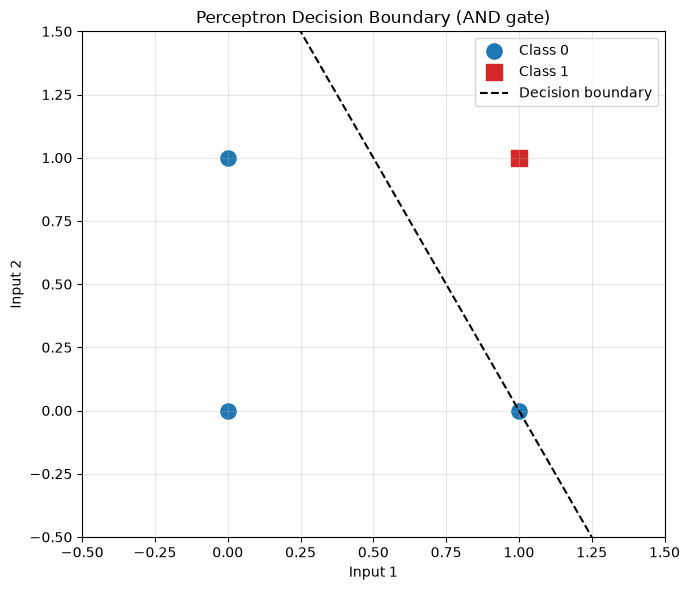

The dashed line is the learned boundary: the class-1 point (1,1) is on
one side and all class-0 points are classified on the other - note the
boundary passes right next to (1,0): the perceptron stops at the FIRST
separating line it finds, not the one with the widest margin.

Example completed successfully!


In [1]:
# The perceptron, implemented from scratch: weighted sum, step activation, and the
# 1958 error-driven learning rule — the ancestor of every neural network you will train.
"""
Unit 4 - Example 1: Simple Perceptron

This example demonstrates:
1. Perceptron implementation
2. Training a perceptron
3. Binary classification
4. Decision boundary visualization
"""

import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("Example 1: Simple Perceptron")
print("=" * 60)

# The whole algorithm lives in this class: predict with a weighted sum, nudge weights on every mistake.
class SimplePerceptron:
    """
    Simple Perceptron for binary classification.
    """
    
    def __init__(self, learning_rate=0.1, epochs=100):
        """
        Initialize perceptron.
        
        Args:
            learning_rate: Learning rate (default: 0.1)
            epochs: Number of full passes over the training data (default: 100).
                    One epoch = one sweep over every sample. It is NOT the same as
                    an iteration (one weight update on one batch) - see Unit 3,
                    lesson 02 for the distinction the whole diploma uses.
        """
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
    
    def activation(self, x):
        """
        Step activation function.
        
        Returns 1 if x >= 0, else 0
        """
        return 1 if x >= 0 else 0
    
    def fit(self, X, y):
        """
        Train the perceptron.
        
        Args:
            X: Input features (n_samples, n_features)
            y: Target labels (0 or 1)
        """
        n_samples, n_features = X.shape
        
        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        print("\nTraining Perceptron...")
        
        for epoch in range(self.epochs):
            errors = 0
            for i in range(n_samples):
                # Forward pass
                linear_output = np.dot(X[i], self.weights) + self.bias
                prediction = self.activation(linear_output)
                
                # Update weights if prediction is wrong
                error = y[i] - prediction
                if error != 0:
                    errors += 1
                    self.weights += self.learning_rate * error * X[i]
                    self.bias += self.learning_rate * error
            
            if errors == 0:
                print(f"  Converged at epoch {epoch + 1}")
                break
            
            if (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch + 1}: {errors} errors")
        
        print(f"\nTraining complete!")
        print(f"Final weights: {self.weights}")
        print(f"Final bias: {self.bias}")
    
    def predict(self, X):
        """
        Make predictions.
        """
        predictions = []
        for i in range(len(X)):
            linear_output = np.dot(X[i], self.weights) + self.bias
            predictions.append(self.activation(linear_output))
        return np.array(predictions)

# Example: AND Gate
print("\n" + "=" * 60)
print("Example: AND Gate Classification")
print("=" * 60)

# Training data for AND gate
# Training data: the AND truth table — linearly separable, so a single perceptron CAN learn it.
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])  # AND gate output

print("\nTraining Data:")
print("Input | Output")
print("------|-------")
for i in range(len(X)):
    print(f"{X[i]}  |   {y[i]}")

# Create and train perceptron
perceptron = SimplePerceptron(learning_rate=0.1, epochs=100)
perceptron.fit(X, y)

# Test the perceptron
print("\n" + "=" * 60)
print("Testing Perceptron")
print("=" * 60)

predictions = perceptron.predict(X)
print("\nPredictions:")
print("Input | Expected | Predicted | Correct")
print("------|----------|-----------|--------")
for i in range(len(X)):
    correct = "✓" if predictions[i] == y[i] else "✗"
    print(f"{X[i]}  |    {y[i]}     |     {predictions[i]}     |   {correct}")

accuracy = np.mean(predictions == y) * 100
print(f"\nAccuracy: {accuracy}%")

# Decision boundary visualization
# The learned rule is: w1*x1 + w2*x2 + b >= 0  ->  class 1
plt.figure(figsize=(7, 6))
for cls, marker, color in [(0, 'o', 'tab:blue'), (1, 's', 'tab:red')]:
    pts = X[y == cls]
    plt.scatter(pts[:, 0], pts[:, 1], marker=marker, s=120, c=color, label=f'Class {cls}')

w1, w2 = perceptron.weights
b = perceptron.bias
xs = np.linspace(-0.5, 1.5, 100)
plt.plot(xs, -(w1 * xs + b) / w2, 'k--', label='Decision boundary')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.title('Perceptron Decision Boundary (AND gate)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('The dashed line is the learned boundary: the class-1 point (1,1) is on')
print('one side and all class-0 points are classified on the other - note the')
print('boundary passes right next to (1,0): the perceptron stops at the FIRST')
print('separating line it finds, not the one with the widest margin.')

print("\n" + "=" * 60)
print("Example completed successfully!")
print("=" * 60)

## 🎬 Watch the boundary move

The log above says *"converged at epoch 4"* — four lines of text for the only thing
that actually happened in this notebook. The cell below replays **the identical
learning rule**, but stores the weights after **every single update**, and draws the
plane the neuron sees at each of those moments: **blue = "this input is a 0", red =
"this input is a 1"**, with a black ring around the row whose mistake caused the update.

Nothing is retrained and nothing is invented — these are the states the rule passed
through on its way to the boundary you already plotted.

8 weight updates in total (one per mistake), then a full pass
with no mistakes at epoch 4.

update | epoch | row corrected |    w1    w2 |      b
--------------------------------------------------------
     0 | start |             - |   0.0   0.0 |   +0.0
     1 |     1 |   [0 0] (y=0) |   0.0   0.0 |   -0.1
     2 |     1 |   [1 1] (y=1) |   0.1   0.1 |   +0.0
     3 |     2 |   [0 0] (y=0) |   0.1   0.1 |   -0.1
     4 |     2 |   [0 1] (y=0) |   0.1   0.0 |   -0.2
     5 |     2 |   [1 1] (y=1) |   0.2   0.1 |   -0.1
     6 |     3 |   [0 1] (y=0) |   0.2   0.0 |   -0.2
     7 |     3 |   [1 0] (y=0) |   0.1   0.0 |   -0.3
     8 |     3 |   [1 1] (y=1) |   0.2   0.1 |   -0.2


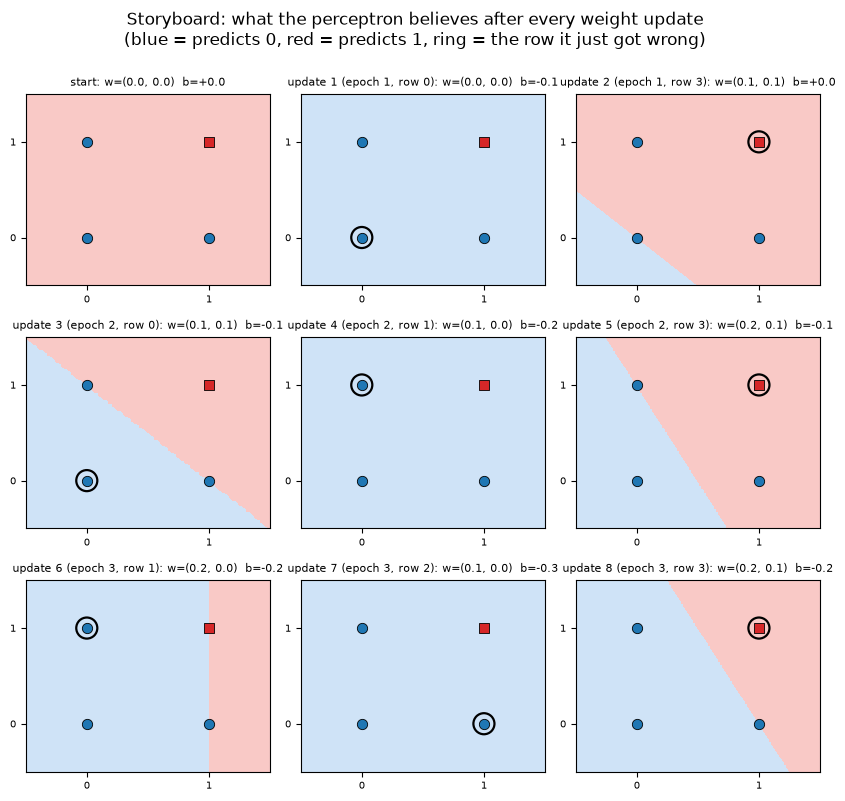

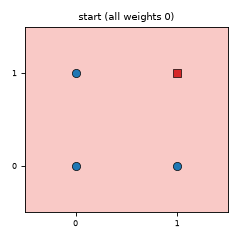

Animation above: 9 frames, one per recorded state, 240x240 pixels each.
Last frame = w [0.2 0.1], b -0.20 — the same boundary as the figure above.


In [2]:
# WHAT/WHY: a printed "converged at epoch 4" hides the process. Here we replay the
# same rule and record (w, b) after every update, then draw the decision REGION at
# each recorded state — a storyboard first (always renders), then the same frames as
# an animation. GIF idiom borrowed from Course 09's course09_step_viz
# (frames_to_gif_bytes / display_gif), kept inline so this notebook stands alone.
import io
from PIL import Image
from IPython.display import Image as IPyImage, display

# --- replay the rule, recording every state it passes through -------------------
w_rec, b_rec = np.zeros(2), 0.0
trail = [(0, None, None, w_rec.copy(), b_rec)]      # (update #, epoch, row, w, b)
for epoch in range(1, 101):
    mistakes = 0
    for i in range(len(X)):
        pred = 1 if X[i] @ w_rec + b_rec >= 0 else 0
        error = y[i] - pred
        if error != 0:                  # WHY: the rule moves ONLY on a mistake
            mistakes += 1
            w_rec = w_rec + 0.1 * error * X[i]
            b_rec = b_rec + 0.1 * error
            trail.append((len(trail), epoch, i, w_rec.copy(), b_rec))
    if mistakes == 0:                   # a full pass with nothing to correct = done
        break

# --- the same story as a table: every update, in order --------------------------
print(f"{len(trail) - 1} weight updates in total (one per mistake), then a full pass")
print(f"with no mistakes at epoch {epoch}.\n")
print(f"{'update':>6} | {'epoch':>5} | {'row corrected':>13} | {'w1':>5} {'w2':>5} | {'b':>6}")
print("-" * 56)
for k, ep, i, ww, bb in trail:
    row = "-" if i is None else f"{X[i]} (y={y[i]})"
    print(f"{k:>6} | {str(ep) if ep else 'start':>5} | {row:>13} | "
          f"{ww[0]:>5.1f} {ww[1]:>5.1f} | {bb:>+6.1f}")

# --- draw the decision REGION for one state (works even when w = 0) -------------
gx, gy = np.meshgrid(np.linspace(-0.5, 1.5, 120), np.linspace(-0.5, 1.5, 120))

def draw_state(ax, ww, bb, corrected_row):
    """Colour every point of the plane by what this neuron would answer."""
    zz = ((gx * ww[0] + gy * ww[1] + bb) >= 0).astype(int)
    ax.contourf(gx, gy, zz, levels=[-0.5, 0.5, 1.5], colors=["#cfe3f7", "#f9c9c6"])
    for cls, marker, color in [(0, 'o', 'tab:blue'), (1, 's', 'tab:red')]:
        pts = X[y == cls]
        ax.scatter(pts[:, 0], pts[:, 1], marker=marker, s=55, c=color,
                   edgecolors='k', linewidths=0.6, zorder=3)
    if corrected_row is not None:       # ring the row whose mistake caused this move
        ax.scatter(*X[corrected_row], s=230, facecolors='none', edgecolors='k',
                   linewidths=1.6, zorder=4)
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1]); ax.tick_params(labelsize=7)

# Keep the storyboard cheap: at most 9 evenly spaced states.
sel = trail if len(trail) <= 9 else [trail[j] for j in
                                     np.linspace(0, len(trail) - 1, 9).astype(int)]

def title_for(k, ep, i, ww, bb):
    if k == 0:
        return "start: w=(0.0, 0.0)  b=+0.0"
    return f"update {k} (epoch {ep}, row {i}): w=({ww[0]:.1f}, {ww[1]:.1f})  b={bb:+.1f}"

fig, axes = plt.subplots(3, 3, figsize=(8.4, 8.0))
for ax, state in zip(axes.ravel(), sel):
    draw_state(ax, state[3], state[4], state[2])
    ax.set_title(title_for(*state), fontsize=8)
for ax in axes.ravel()[len(sel):]:
    ax.axis("off")
fig.suptitle("Storyboard: what the perceptron believes after every weight update\n"
             "(blue = predicts 0, red = predicts 1, ring = the row it just got wrong)",
             y=0.995)
plt.tight_layout()
plt.show()

# --- the same frames as an animation --------------------------------------------
def frames_to_gif_bytes(frames, duration_ms=800):
    """Encode uint8 RGB frames as one animated GIF (Course 09 step-viz idiom)."""
    imgs = [Image.fromarray(np.asarray(f, dtype=np.uint8)) for f in frames]
    buf = io.BytesIO()
    imgs[0].save(buf, format="GIF", save_all=True, append_images=imgs[1:],
                 duration=duration_ms, loop=0)
    return buf.getvalue()

def fig_to_rgb(fig):
    """Render a matplotlib figure into an RGB array (all frames share one size)."""
    fig.canvas.draw()
    rgb = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
    plt.close(fig)
    return rgb

frames = []
for state in sel:
    f, ax = plt.subplots(figsize=(3.0, 3.0), dpi=80)
    draw_state(ax, state[3], state[4], state[2])
    k = state[0]
    ax.set_title("start (all weights 0)" if k == 0 else
                 f"update {k}: w=({state[3][0]:.1f}, {state[3][1]:.1f}) b={state[4]:+.1f}",
                 fontsize=9)
    f.tight_layout()
    frames.append(fig_to_rgb(f))

display(IPyImage(data=frames_to_gif_bytes(frames), format="gif"))
print(f"Animation above: {len(frames)} frames, one per recorded state, "
      f"{frames[0].shape[1]}x{frames[0].shape[0]} pixels each.")
print(f"Last frame = w {np.round(sel[-1][3], 2)}, b {sel[-1][4]:+.2f} — the same "
      f"boundary as the figure above.")


### 👀 Read the storyboard

- **Panel "start"** is entirely red. With `w = (0, 0)` and `b = 0` every input scores
  `z = 0`, and the step rule counts `z ≥ 0` as class 1 — so before it learns anything,
  this neuron answers **"AND is true"** for all four rows. That is not a neutral
  starting point; it is a wrong opinion held everywhere.
- **Panel 1** flips the entire plane to blue. One mistake on `(0, 0)` pushed the bias
  to −0.1, and with weights still zero *every* input now scores below zero. The neuron
  swung from "always 1" to "always 0" on the strength of a single row.
- **From panel 2 onwards a real border appears** and swings back and forth: each ringed
  point is the row that was wrong, and the border always moves so that this row ends up
  on the correct side. Nothing moves when nothing is wrong — the table lists **8**
  updates across the first three epochs, not 12, because correctly classified rows leave
  the weights untouched.
- **Panel 6 is the instructive failure.** With `w = (0.2, 0.0)`, `b = −0.2` the border
  passes *exactly* through the point `(1, 0)`, and the step rule scores `z = 0` as class
  1 — so that row is wrong, and panel 7 is the correction.
- **Panel 8 is the boundary you plotted above** (`w = (0.2, 0.1)`, `b = −0.20`): a red wedge in the
  top-right corner that contains `(1, 1)` and none of the three zero-rows. The fourth epoch adds no panel at all, because it
  makes no mistakes — and that silence *is* convergence.

The whole of learning, in this model, is that picture: **be wrong, move the line, repeat.**

## 💬 Discuss

The run converged at **epoch 4** with weights `[0.2, 0.1]` and bias `-0.2`, and
scored 100% on the AND gate.

1. Read the learned parameters as a sentence. The neuron fires when
   `0.2·x₁ + 0.1·x₂ > 0.2`. Check each of the four AND rows by hand against that
   inequality. Now find *another* pair of weights that also classifies all four
   correctly. **What does the existence of many correct answers tell you about
   what "the model learned" means?**
2. The perceptron rule converges in a finite number of steps *if* the data is
   linearly separable, and never terminates if it is not — and it gives you no
   signal to distinguish the two cases. You are handed an unfamiliar dataset and
   the run has been going for an hour. **What do you check, in what order?**
3. AND, OR and NOT are separable; XOR is not. Think about a real classification
   task you might face — approving a loan, flagging a faulty part, marking an
   exam. **Would you expect a single straight line to be enough?** Name the
   feature interaction that you think would break it.


---

## ✅ Summary

Great job completing this example!

**What you learned:**
- Core concepts demonstrated in the code
- Practical implementation details

**Next steps:**
- Complete the exercises in `exercises/` folder
- Review the quiz materials
- Proceed to the next example

---

**💡 Tip:** If you see errors, make sure:
- All libraries are installed: `pip install -r requirements.txt`
- You're using Python 3.8+
- Cells are executed in order

## ⚠️ Where this breaks

- **The perceptron rule only converges on linearly separable data.** Novikoff
  proved convergence in 1962 — for separable data. On non-separable data it
  oscillates forever, and the weights at the moment you stop it are whatever the
  last few misclassified points pushed them to, not a best fit. **Use instead:**
  logistic regression, which minimises a loss and therefore always has a best
  answer even when no perfect line exists.
- **The step activation has zero gradient everywhere it is defined.** That is the
  deep reason a perceptron cannot be stacked: there is no signal to send back to a
  hidden layer. Everything in Unit 4 from notebook 03 onward replaces the step
  with a smooth activation for exactly this reason.
- **It outputs a hard 0 or 1 and no confidence.** A point one millimetre past the
  boundary and one metre past it get identical output. For anything that needs a
  probability — ranking, thresholding, risk — this is unusable.
- **AND is not a benchmark.** Four rows, no test set, no noise, no missing values,
  no class imbalance. Convergence in four epochs tells you the implementation is
  correct and nothing at all about the method's performance.
- **The result depends on the initialisation and the presentation order** of the
  training rows. Different starting weights give a different final boundary — all
  correct, none canonical.
- **When a perceptron is still worth it:** almost never as a model, and almost
  always as a *baseline*. If a linear model on your features already does the job,
  a deep network buys you cost, opacity and an explanation problem for nothing.


## 📚 References

1. McCulloch, W. S., & Pitts, W. (1943). *A Logical Calculus of the Ideas Immanent in Nervous Activity*. Bulletin of Mathematical Biophysics, 5, 115–133.
2. Rosenblatt, F. (1958). *The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain*. Psychological Review, 65(6), 386–408.
3. Minsky, M., & Papert, S. (1969). *Perceptrons: An Introduction to Computational Geometry*. MIT Press.
4. OpenAI (2025). *gpt-oss-120b & gpt-oss-20b Model Card*. arXiv. <https://arxiv.org/abs/2508.10925>
5. Nguyen, C. V., Shen, X., Aponte, R., et al. (2024). *A Survey of Small Language Models*. arXiv. <https://arxiv.org/abs/2410.20011>